In [1]:
import sys
import os
import matplotlib.pyplot as plt
# Add the project root to the Python path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from crater_analysis.io import read_crater_locations, read_dem
from crater_analysis.analysis import filter_craters, get_crater_profile, get_dem_snippet
from crater_analysis.plotting import plot_dem, plot_crater_locations
from crater_analysis.core import Crater


dem, metadata = read_dem('../data/dems/LDEM_60S_120M.JP2')

Successfully read DEM from ../data/dems/LDEM_60S_120M.JP2


In [2]:
lat = 'LAT_CIRC_IMG'
lon = 'LON_CIRC_IMG'
diam = 'DIAM_CIRC_IMG'

craters = read_crater_locations('../data/catalogs/lunar_crater_database_robbins_2018.csv')
craters = filter_craters(craters, pole='south', lat_threshold=60, circ_threshold=None, diam_min=8, diam_max=None, lat_col=lat, diam_col=diam)

#craters = read_crater_locations('../data/catalogs/moon_data.csv')
#craters = filter_craters(craters, pole='south', lat_threshold=60, circ_threshold=0.85, diam_min=8000, diam_max=None, lat_col=lat, diam_col=diam)

craters.head()

Successfully read 1296796 crater locations from ../data/catalogs/lunar_crater_database_robbins_2018.csv
Filtered to 2511 craters matching criteria.


,CRATER_ID,LAT_CIRC_IMG,LON_CIRC_IMG,LAT_ELLI_IMG,LON_ELLI_IMG,DIAM_CIRC_IMG,DIAM_CIRC_SD_IMG,DIAM_ELLI_MAJOR_IMG,DIAM_ELLI_MINOR_IMG,DIAM_ELLI_ECCEN_IMG,...,DIAM_ELLI_ANGLE_IMG,LAT_ELLI_SD_IMG,LON_ELLI_SD_IMG,DIAM_ELLI_MAJOR_SD_IMG,DIAM_ELLI_MINOR_SD_IMG,DIAM_ELLI_ANGLE_SD_IMG,DIAM_ELLI_ECCEN_SD_IMG,DIAM_ELLI_ELLIP_SD_IMG,ARC_IMG,PTS_RIM_IMG
22,00-1-000022,-69.0838,111.7080,-69.6198,112.8180,296.91100,8.236020,349.56300,292.90900,0.545778,...,126.9250,0.116851,0.302118,11.312900,1.653770,1.838590,0.042263,0.039206,0.273877,245
392503,03-1-161306,-60.0159,240.2810,-60.0299,240.2960,16.14920,0.627066,17.96500,15.11360,0.540602,...,127.8280,0.004110,0.004630,0.301956,0.134482,2.985280,0.024898,0.022606,0.793966,91
650324,07-1-002670,-60.1712,69.8990,-60.1545,69.8455,34.37330,0.844505,35.47040,31.47940,0.460837,...,53.7096,0.002239,0.003996,0.118923,0.183363,1.276750,0.011487,0.007573,0.656386,271
827677,07-1-227330,-60.0047,41.5605,-60.0037,41.5823,8.59538,0.182044,8.86766,7.56926,0.520961,...,91.1537,0.000970,0.002900,0.046377,0.093363,2.451100,0.018737,0.015696,0.663200,36
828210,07-2-000103,-60.2111,11.7462,-60.3188,12.2347,56.42690,2.279950,60.89500,40.27900,0.749990,...,89.8699,0.006955,0.014686,0.437777,0.470050,0.769305,0.007996,0.020722,0.276096,190


In [3]:
### Initialise Craters ###
# Create an empty list to hold the Crater objects
crater_objects = []

# Loop through the first few rows of the DataFrame for demonstration
# To process all craters, change `craters.head(1).iterrows()` to `craters.iterrows()`
for index, row in craters.head(100).iterrows():
    # Extract crater properties from the row
    crater_id = None #row['CRATER_ID']
    crater_lon = row[lon]
    crater_lat = row[lat]
    crater_diam_km = row[diam] #/1000.0  # Convert diameter from meters to kilometers
    
    # Get the DEM snippet for this crater
    dem_snippet, snippet_meta, center_coords = get_dem_snippet(
        dem,
        metadata,
        crater_lon,
        crater_lat,
        crater_diam_km,
        padding_factor=1.5
    )
    
    # Create the Crater object
    crater_obj = Crater(
        crater_id=crater_id,
        dem_snippet=dem_snippet,
        metadata=snippet_meta,
        center_coords=center_coords,
        global_coords={'lon': crater_lon, 'lat': crater_lat},
    )
    
    crater_obj.add_property('diameter_km', crater_diam_km)

    # Add the new object to our list
    crater_objects.append(crater_obj)

# Print a summary to confirm it worked
print(f"Successfully initialized {len(crater_objects)} Crater objects.")
if crater_objects:
    print("First crater object in the list:")
    print(crater_objects[0])
    print(crater_objects[0].dem_data)
print(dem)

Successfully initialized 100 Crater objects.
First crater object in the list:
Crater(id=None, center=(1855.953084437284, 1855.8453471291723), global_coords={'lon': 111.708, 'lat': -69.0838}, properties=['diameter_km'])
[[ 3411  3353  3289 ... -2540 -2605 -2668]
 [ 3405  3345  3284 ... -2530 -2592 -2655]
 [ 3417  3352  3285 ... -2518 -2577 -2641]
 ...
 [-7564 -7570 -7576 ...  5333  5331  5320]
 [-7559 -7566 -7567 ...  5388  5388  5380]
 [-7551 -7551 -7552 ...  5444  5441  5428]]
[[ 1111  1107  1100 ...   118   127   132]
 [ 1122  1116  1108 ...   100   108   107]
 [ 1136  1128  1117 ...    72    77    77]
 ...
 [-7393 -7374 -7350 ... -2913 -2915 -2914]
 [-7407 -7387 -7361 ... -2920 -2918 -2917]
 [-7420 -7396 -7369 ... -2919 -2917 -2919]]


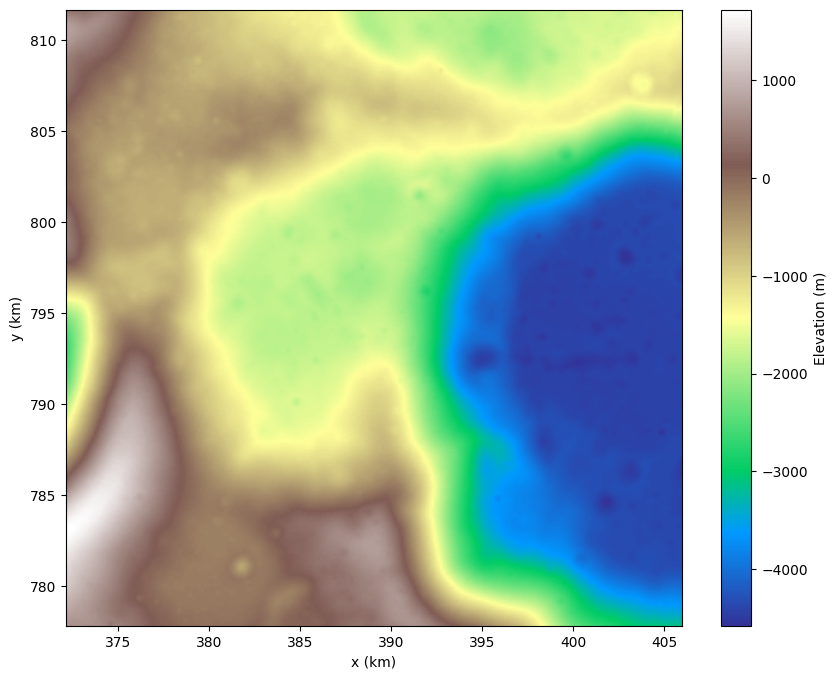

(<Figure size 1000x800 with 2 Axes>, <Axes: xlabel='x (km)', ylabel='y (km)'>)

In [4]:
plot_dem(crater_objects[51].dem_data, crater_objects[51].metadata)

## Extract a 2D Profile from a Crater

The `get_crater_profile` function uses Bresenham's line algorithm to sample actual pixel values along the profile, giving you the true DEM resolution without any interpolation.

Parameters:
- `dem_data`: The DEM array (can be the full DEM or a snippet)
- `metadata`: The corresponding metadata
- `crater_lon`, `crater_lat`: The crater's center coordinates
- `crater_diam_km`: The crater's diameter in kilometers
- `angle`: Angle of the profile in degrees (0=horizontal/E-W, 90=vertical/N-S)

Horizontal profile: 160 pixels, slope=500.02 m/km
Vertical profile: 160 pixels, slope=695.00 m/km


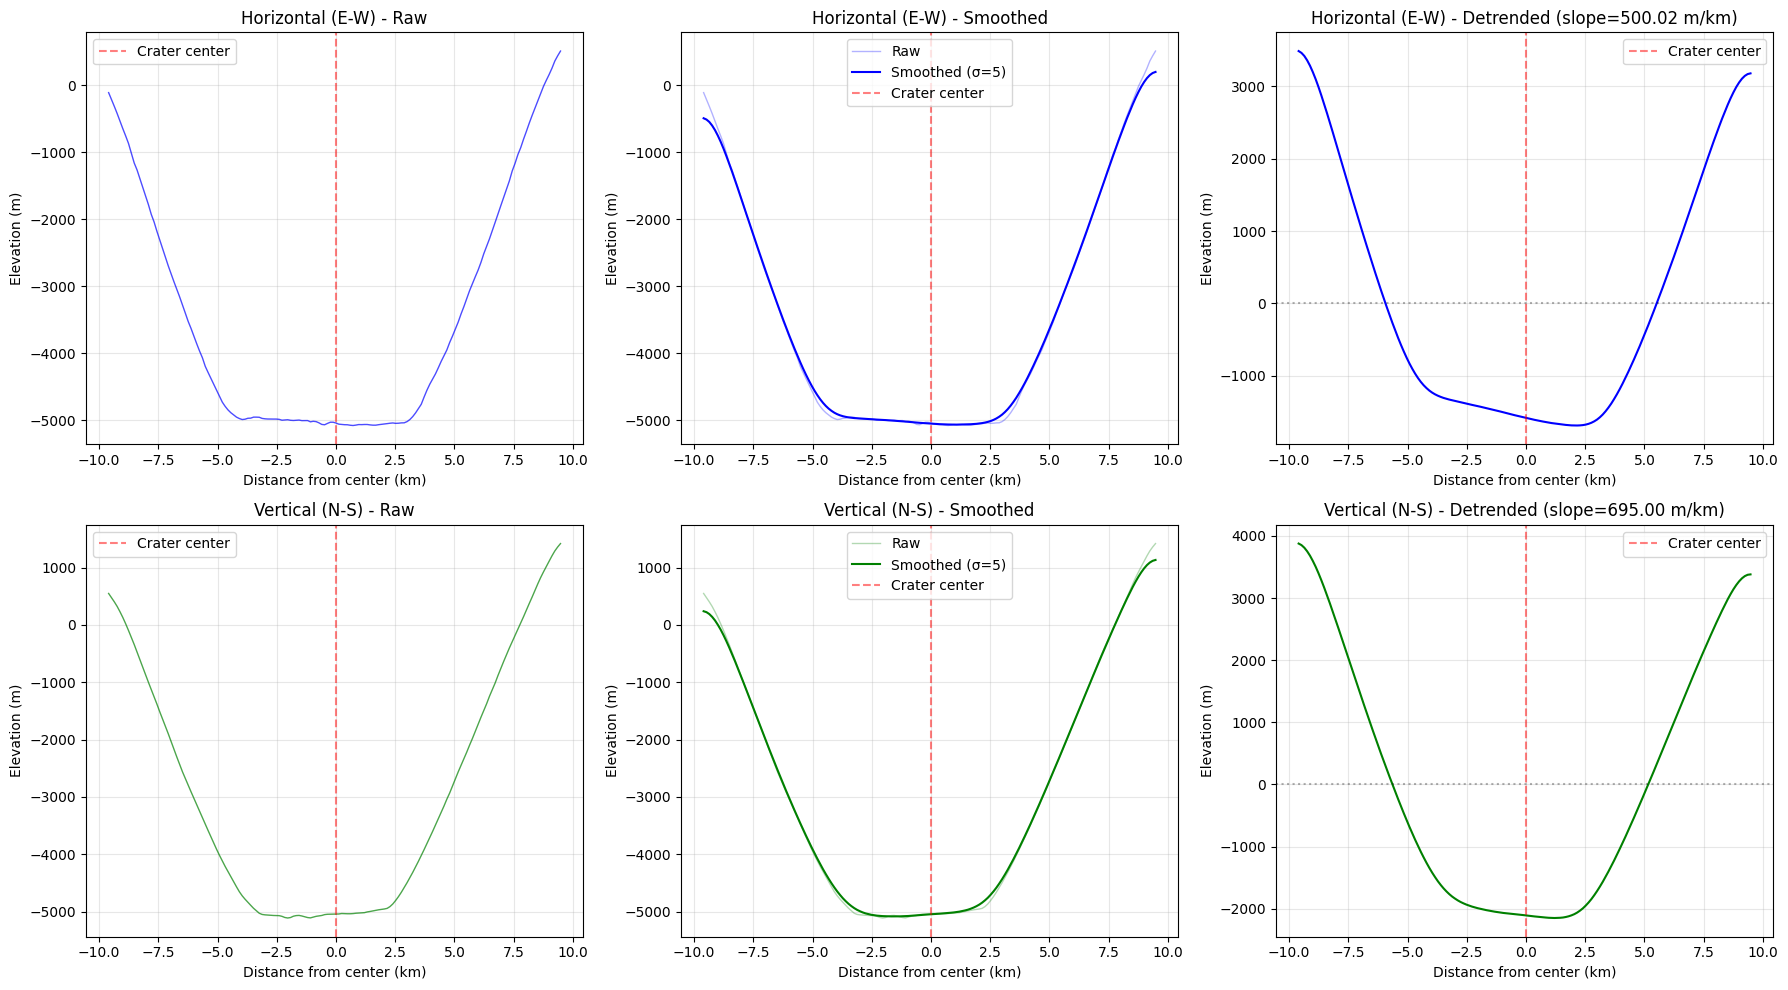

In [36]:
# Import the analysis functions
from crater_analysis.analysis import detrend_profile, smooth_profile

# Extract profiles in both horizontal and vertical directions
crater = crater_objects[50]

# Horizontal profile (E-W, angle=0)
distance_h, elevation_h, pixel_coords_h = get_crater_profile(
    crater.dem_data,
    crater.metadata,
    crater.global_coords['lon'],
    crater.global_coords['lat'],
    crater_diam_km=crater.get_property('diameter_km') * 1,
    angle=0  # 0 degrees = horizontal (E-W)
)

# Vertical profile (N-S, angle=90)
distance_v, elevation_v, pixel_coords_v = get_crater_profile(
    crater.dem_data,
    crater.metadata,
    crater.global_coords['lon'],
    crater.global_coords['lat'],
    crater_diam_km=crater.get_property('diameter_km') * 1,
    angle=90  # 90 degrees = vertical (N-S)
)

# Apply Gaussian smoothing to remove small-scale noise
# sigma controls the amount of smoothing (larger = more smoothing)
sigma = 5  # Try values between 1-5 depending on noise level
elevation_h_smooth = smooth_profile(elevation_h, sigma=sigma)
elevation_v_smooth = smooth_profile(elevation_v, sigma=sigma)

# Detrend the smoothed profiles to remove regional slope
elevation_h_detrended, slope_h, intercept_h = detrend_profile(distance_h, elevation_h_smooth)
elevation_v_detrended, slope_v, intercept_v = detrend_profile(distance_v, elevation_v_smooth)

print(f"Horizontal profile: {len(elevation_h)} pixels, slope={slope_h:.2f} m/km")
print(f"Vertical profile: {len(elevation_v)} pixels, slope={slope_v:.2f} m/km")

# Plot raw, smoothed, and detrended profiles
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Horizontal profile - Raw
axes[0, 0].plot(distance_h, elevation_h, '-', linewidth=1, color='blue', alpha=0.7)
axes[0, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[0, 0].set_xlabel('Distance from center (km)')
axes[0, 0].set_ylabel('Elevation (m)')
axes[0, 0].set_title(f'Horizontal (E-W) - Raw')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Horizontal profile - Smoothed
axes[0, 1].plot(distance_h, elevation_h, '-', linewidth=1, color='blue', alpha=0.3, label='Raw')
axes[0, 1].plot(distance_h, elevation_h_smooth, '-', linewidth=1.5, color='blue', label=f'Smoothed (σ={sigma})')
axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[0, 1].set_xlabel('Distance from center (km)')
axes[0, 1].set_ylabel('Elevation (m)')
axes[0, 1].set_title(f'Horizontal (E-W) - Smoothed')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Horizontal profile - Detrended
axes[0, 2].plot(distance_h, elevation_h_detrended, '-', linewidth=1.5, color='blue')
axes[0, 2].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[0, 2].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 2].set_xlabel('Distance from center (km)')
axes[0, 2].set_ylabel('Elevation (m)')
axes[0, 2].set_title(f'Horizontal (E-W) - Detrended (slope={slope_h:.2f} m/km)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Vertical profile - Raw
axes[1, 0].plot(distance_v, elevation_v, '-', linewidth=1, color='green', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[1, 0].set_xlabel('Distance from center (km)')
axes[1, 0].set_ylabel('Elevation (m)')
axes[1, 0].set_title(f'Vertical (N-S) - Raw')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Vertical profile - Smoothed
axes[1, 1].plot(distance_v, elevation_v, '-', linewidth=1, color='green', alpha=0.3, label='Raw')
axes[1, 1].plot(distance_v, elevation_v_smooth, '-', linewidth=1.5, color='green', label=f'Smoothed (σ={sigma})')
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[1, 1].set_xlabel('Distance from center (km)')
axes[1, 1].set_ylabel('Elevation (m)')
axes[1, 1].set_title(f'Vertical (N-S) - Smoothed')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Vertical profile - Detrended
axes[1, 2].plot(distance_v, elevation_v_detrended, '-', linewidth=1.5, color='green')
axes[1, 2].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[1, 2].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 2].set_xlabel('Distance from center (km)')
axes[1, 2].set_ylabel('Elevation (m)')
axes[1, 2].set_title(f'Vertical (N-S) - Detrended (slope={slope_v:.2f} m/km)')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Horizontal profile floor: distance=0.120 km, elevation=-1589.38 m
Vertical profile floor: distance=0.240 km, elevation=-2116.87 m


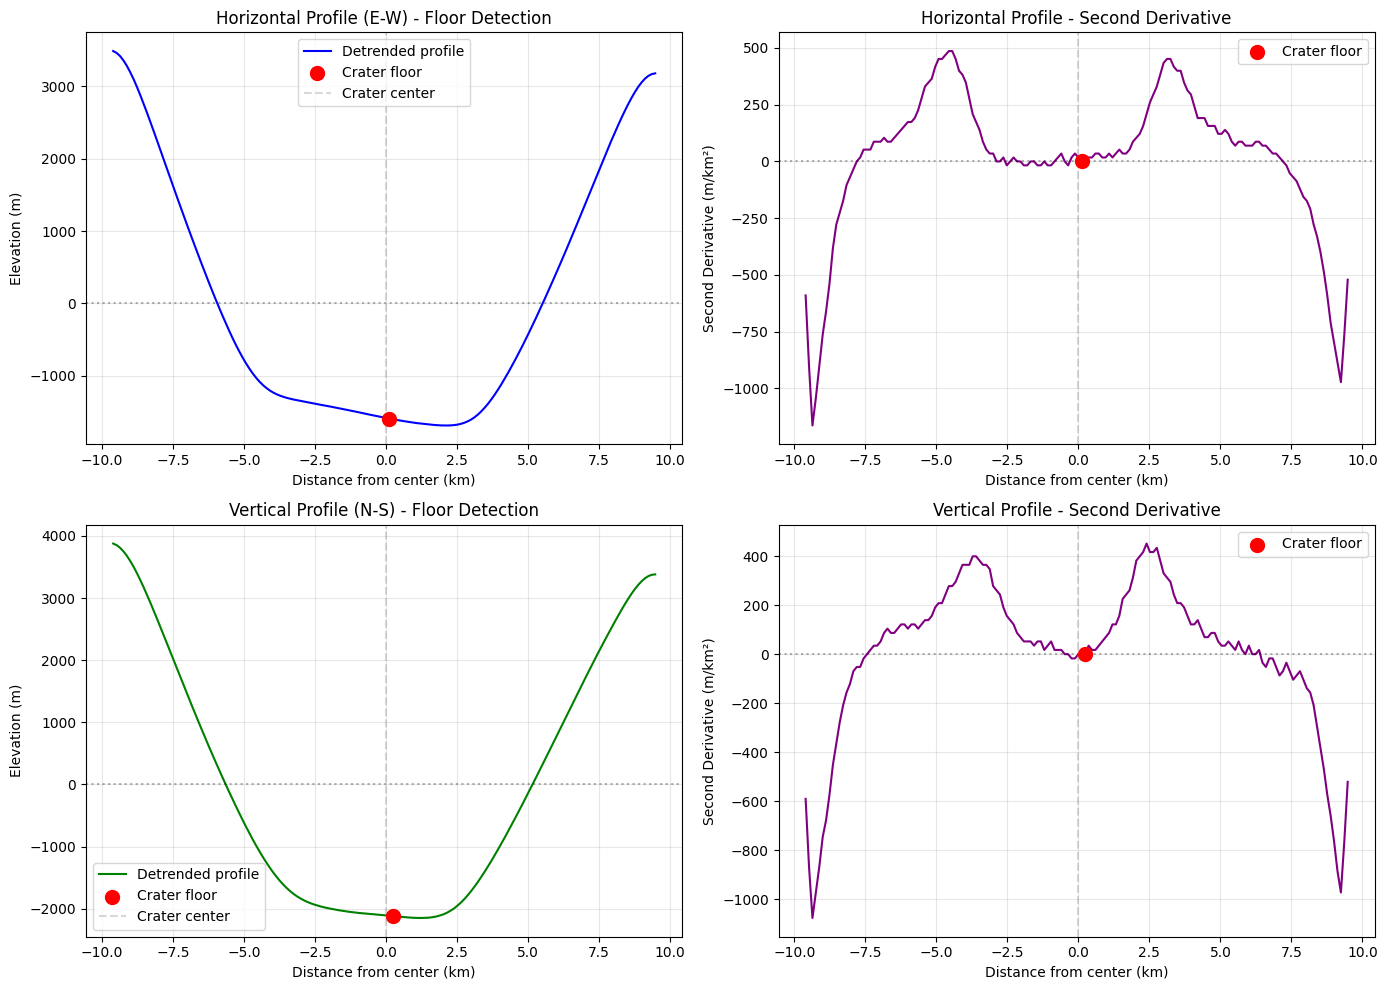

In [37]:
# Import the crater floor finding function
from crater_analysis.analysis import find_crater_floor

# Find the deepest point in the horizontal profile
floor_idx_h, floor_dist_h, floor_elev_h, second_deriv_h = find_crater_floor(distance_h, elevation_h_detrended)

# Find the deepest point in the vertical profile
floor_idx_v, floor_dist_v, floor_elev_v, second_deriv_v = find_crater_floor(distance_v, elevation_v_detrended)

print(f"Horizontal profile floor: distance={floor_dist_h:.3f} km, elevation={floor_elev_h:.2f} m")
print(f"Vertical profile floor: distance={floor_dist_v:.3f} km, elevation={floor_elev_v:.2f} m")

# Plot the profiles with the identified floor locations and second derivatives
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Horizontal profile with floor marked
axes[0, 0].plot(distance_h, elevation_h_detrended, '-', linewidth=1.5, color='blue', label='Detrended profile')
axes[0, 0].scatter(floor_dist_h, floor_elev_h, color='red', s=100, zorder=5, label='Crater floor')
axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Crater center')
axes[0, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 0].set_xlabel('Distance from center (km)')
axes[0, 0].set_ylabel('Elevation (m)')
axes[0, 0].set_title('Horizontal Profile (E-W) - Floor Detection')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Horizontal second derivative
axes[0, 1].plot(distance_h, second_deriv_h, '-', linewidth=1.5, color='purple')
axes[0, 1].scatter(floor_dist_h, second_deriv_h[floor_idx_h], color='red', s=100, zorder=5, label='Crater floor')
axes[0, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.3)
axes[0, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 1].set_xlabel('Distance from center (km)')
axes[0, 1].set_ylabel('Second Derivative (m/km²)')
axes[0, 1].set_title('Horizontal Profile - Second Derivative')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Vertical profile with floor marked
axes[1, 0].plot(distance_v, elevation_v_detrended, '-', linewidth=1.5, color='green', label='Detrended profile')
axes[1, 0].scatter(floor_dist_v, floor_elev_v, color='red', s=100, zorder=5, label='Crater floor')
axes[1, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Crater center')
axes[1, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 0].set_xlabel('Distance from center (km)')
axes[1, 0].set_ylabel('Elevation (m)')
axes[1, 0].set_title('Vertical Profile (N-S) - Floor Detection')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Vertical second derivative
axes[1, 1].plot(distance_v, second_deriv_v, '-', linewidth=1.5, color='purple')
axes[1, 1].scatter(floor_dist_v, second_deriv_v[floor_idx_v], color='red', s=100, zorder=5, label='Crater floor')
axes[1, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.3)
axes[1, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 1].set_xlabel('Distance from center (km)')
axes[1, 1].set_ylabel('Second Derivative (m/km²)')
axes[1, 1].set_title('Vertical Profile - Second Derivative')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Import the crater rim finding function
from crater_analysis.analysis import find_crater_rims

# Find the rims for both profiles
left_rim_idx_h, right_rim_idx_h, left_rim_dist_h, right_rim_dist_h, first_deriv_h = find_crater_rims(
    distance_h, elevation_h_detrended, floor_idx_h, threshold_fraction=0.1
)

left_rim_idx_v, right_rim_idx_v, left_rim_dist_v, right_rim_dist_v, first_deriv_v = find_crater_rims(
    distance_v, elevation_v_detrended, floor_idx_v, threshold_fraction=0.1
)

# Calculate diameters
diameter_h = right_rim_dist_h - left_rim_dist_h
diameter_v = right_rim_dist_v - left_rim_dist_v

print(f"Horizontal profile:")
print(f"  Left rim: {left_rim_dist_h:.3f} km, Right rim: {right_rim_dist_h:.3f} km")
print(f"  Measured diameter: {diameter_h:.3f} km")
print(f"\nVertical profile:")
print(f"  Left rim: {left_rim_dist_v:.3f} km, Right rim: {right_rim_dist_v:.3f} km")
print(f"  Measured diameter: {diameter_v:.3f} km")
print(f"\nCatalog diameter: {crater.get_property('diameter_km'):.3f} km")

# Plot the profiles with floor and rims marked
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Horizontal profile with rims
axes[0, 0].plot(distance_h, elevation_h_detrended, '-', linewidth=1.5, color='blue', label='Detrended profile')
axes[0, 0].scatter(floor_dist_h, floor_elev_h, color='red', s=100, zorder=5, label='Floor')
axes[0, 0].scatter([left_rim_dist_h, right_rim_dist_h], 
                   [elevation_h_detrended[left_rim_idx_h], elevation_h_detrended[right_rim_idx_h]], 
                   color='orange', s=100, marker='^', zorder=5, label='Rims')
axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Crater center')
axes[0, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 0].set_xlabel('Distance from center (km)')
axes[0, 0].set_ylabel('Elevation (m)')
axes[0, 0].set_title(f'Horizontal (E-W) - Diameter: {diameter_h:.3f} km')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Horizontal first derivative
axes[0, 1].plot(distance_h, first_deriv_h, '-', linewidth=1.5, color='green')
axes[0, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 1].scatter([left_rim_dist_h, right_rim_dist_h],
                   [first_deriv_h[left_rim_idx_h], first_deriv_h[right_rim_idx_h]],
                   color='orange', s=100, marker='^', zorder=5, label='Rim locations')
axes[0, 1].axvline(x=floor_dist_h, color='red', linestyle='--', alpha=0.5, label='Floor')
axes[0, 1].set_xlabel('Distance from center (km)')
axes[0, 1].set_ylabel('First Derivative (slope)')
axes[0, 1].set_title('Horizontal - First Derivative (Slope)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Vertical profile with rims
axes[1, 0].plot(distance_v, elevation_v_detrended, '-', linewidth=1.5, color='blue', label='Detrended profile')
axes[1, 0].scatter(floor_dist_v, floor_elev_v, color='red', s=100, zorder=5, label='Floor')
axes[1, 0].scatter([left_rim_dist_v, right_rim_dist_v],
                   [elevation_v_detrended[left_rim_idx_v], elevation_v_detrended[right_rim_idx_v]],
                   color='orange', s=100, marker='^', zorder=5, label='Rims')
axes[1, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Crater center')
axes[1, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 0].set_xlabel('Distance from center (km)')
axes[1, 0].set_ylabel('Elevation (m)')
axes[1, 0].set_title(f'Vertical (N-S) - Diameter: {diameter_v:.3f} km')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Vertical first derivative
axes[1, 1].plot(distance_v, first_deriv_v, '-', linewidth=1.5, color='green')
axes[1, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 1].scatter([left_rim_dist_v, right_rim_dist_v],
                   [first_deriv_v[left_rim_idx_v], first_deriv_v[right_rim_idx_v]],
                   color='orange', s=100, marker='^', zorder=5, label='Rim locations')
axes[1, 1].axvline(x=floor_dist_v, color='red', linestyle='--', alpha=0.5, label='Floor')
axes[1, 1].set_xlabel('Distance from center (km)')
axes[1, 1].set_ylabel('First Derivative (slope)')
axes[1, 1].set_title('Vertical - First Derivative (Slope)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Find Crater Rims Using First Derivative

Following the Rubanenko et al. method: starting from the crater floor, find the steepest slope on each side, then locate where the slope decreases to 10% of that maximum.